In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_colwidth', 200)
sns.set_style("whitegrid")

In [2]:
train_df = pd.read_csv('data/raw/train.csv')
test_df = pd.read_csv('data/raw/test.csv')
test_labels_df = pd.read_csv('data/raw/test_labels.csv')
sample_submission_df = pd.read_csv('data/raw/sample_submission.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test labels shape:", test_labels_df.shape)
print("Sample submission shape:", sample_submission_df.shape)

Train shape: (159571, 8)
Test shape: (153164, 2)
Test labels shape: (153164, 7)
Sample submission shape: (153164, 7)


In [3]:
print("Test Null values:\n", test_df.isnull().sum())
print("Test Duplicates:", test_df.duplicated().sum())
print("Test empty comments:", (test_df['comment_text'].str.strip() == '').sum())
print(test_df['comment_text'].str.len().describe())

Test Null values:
 id              0
comment_text    0
dtype: int64
Test Duplicates: 0
Test empty comments: 1
count    153164.000000
mean        364.875121
std         592.492099
min           1.000000
25%          79.000000
50%         180.000000
75%         392.000000
max        5000.000000
Name: comment_text, dtype: float64


In [28]:
print("Train Null values:\n", train_df.isnull().sum())
print("Train Duplicates:", train_df.duplicated().sum())
print("Train empty comments:", (train_df['comment_text'].str.strip() == '').sum())
print(train_df['comment_text'].str.len().describe())

Train Null values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
num_labels       0
dtype: int64
Train Duplicates: 0
Train empty comments: 0
count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: comment_text, dtype: float64


In [5]:
print(test_labels_df.head())
print("\nUnique values per label column:")
for col in ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']:
    print(col, ":", test_labels_df[col].unique())

                 id  toxic  severe_toxic  obscene  threat  insult  \
0  00001cee341fdb12     -1            -1       -1      -1      -1   
1  0000247867823ef7     -1            -1       -1      -1      -1   
2  00013b17ad220c46     -1            -1       -1      -1      -1   
3  00017563c3f7919a     -1            -1       -1      -1      -1   
4  00017695ad8997eb     -1            -1       -1      -1      -1   

   identity_hate  
0             -1  
1             -1  
2             -1  
3             -1  
4             -1  

Unique values per label column:
toxic : [-1  0  1]
severe_toxic : [-1  0  1]
obscene : [-1  0  1]
threat : [-1  0  1]
insult : [-1  0  1]
identity_hate : [-1  0  1]


In [6]:
neg_one_count = (test_labels_df[['toxic','severe_toxic','obscene','threat','insult','identity_hate']] == -1).any(axis=1).sum()
print(f"Rows with -1 (unusable) labels: {neg_one_count} out of {len(test_labels_df)}")

Rows with -1 (unusable) labels: 89186 out of 153164


In [7]:
test_merged = test_df.merge(test_labels_df, on='id')
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

usable_test = test_merged[~(test_merged[label_cols] == -1).any(axis=1)]
print("Usable test rows for evaluation:", len(usable_test))
print("Discarded (-1) rows:", len(test_merged) - len(usable_test))

Usable test rows for evaluation: 63978
Discarded (-1) rows: 89186


In [8]:
print(sample_submission_df.head())
print(sample_submission_df.shape)

                 id  toxic  severe_toxic  obscene  threat  insult  \
0  00001cee341fdb12    0.5           0.5      0.5     0.5     0.5   
1  0000247867823ef7    0.5           0.5      0.5     0.5     0.5   
2  00013b17ad220c46    0.5           0.5      0.5     0.5     0.5   
3  00017563c3f7919a    0.5           0.5      0.5     0.5     0.5   
4  00017695ad8997eb    0.5           0.5      0.5     0.5     0.5   

   identity_hate  
0            0.5  
1            0.5  
2            0.5  
3            0.5  
4            0.5  
(153164, 7)


toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


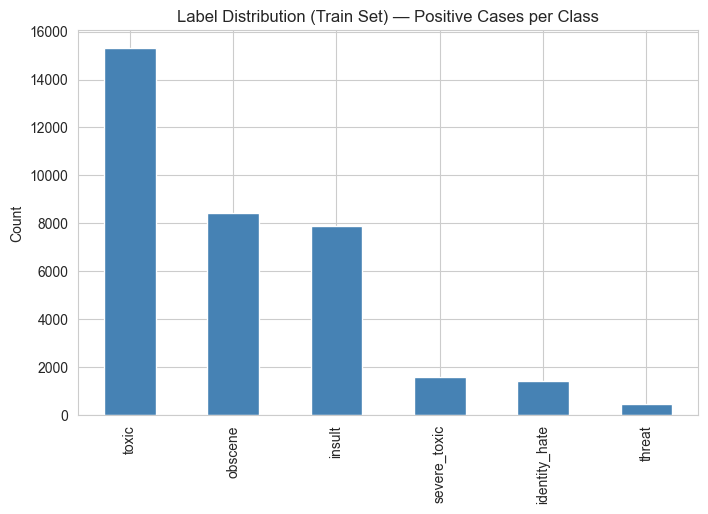

In [9]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

plt.figure(figsize=(8,5))
label_counts.plot(kind='bar', color='steelblue')
plt.title("Label Distribution (Train Set) — Positive Cases per Class")
plt.ylabel("Count")
plt.show()

In [10]:
total = len(train_df)
for col in label_cols:
    pos = train_df[col].sum()
    print(f"{col}: {pos} positive ({pos/total*100:.2f}%)")

toxic: 15294 positive (9.58%)
severe_toxic: 1595 positive (1.00%)
obscene: 8449 positive (5.29%)
threat: 478 positive (0.30%)
insult: 7877 positive (4.94%)
identity_hate: 1405 positive (0.88%)


In [11]:
train_df['num_labels'] = train_df[label_cols].sum(axis=1)
print(train_df['num_labels'].value_counts().sort_index())

# Kitne comments bilkul clean hain (koi label nahi)
clean_comments = (train_df['num_labels'] == 0).sum()
print(f"\nClean comments (no label): {clean_comments} ({clean_comments/total*100:.2f}%)")

num_labels
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

Clean comments (no label): 143346 (89.83%)


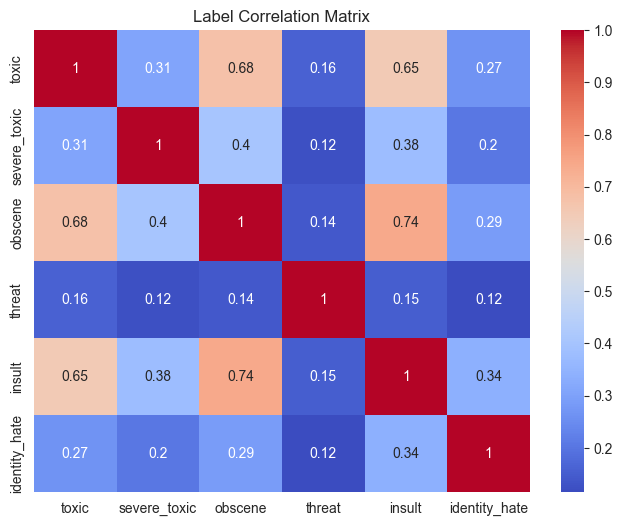

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(train_df[label_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Label Correlation Matrix")
plt.show()

In [13]:
# IP address pattern check
ip_pattern = r'\b(?:\d{1,3}\.){3}\d{1,3}\b'
has_ip = train_df['comment_text'].str.contains(ip_pattern, regex=True, na=False)
print("Comments with IP addresses:", has_ip.sum())

# URL check
url_pattern = r'http\S+|www\S+'
has_url = train_df['comment_text'].str.contains(url_pattern, regex=True, na=False)
print("Comments with URLs:", has_url.sum())

# HTML entity check (e.g. &amp;, &quot;)
html_entity_pattern = r'&[a-z]+;'
has_html = train_df['comment_text'].str.contains(html_entity_pattern, regex=True, na=False)
print("Comments with HTML entities:", has_html.sum())

# Newline/tab check
has_newline = train_df['comment_text'].str.contains(r'\n', regex=True, na=False)
print("Comments with newlines:", has_newline.sum())

Comments with IP addresses: 9816
Comments with URLs: 5151
Comments with HTML entities: 821
Comments with newlines: 94466


In [14]:
# Actual examples dekhna (sirf print karna, samajhne ke liye)
print("Sample with IP address:")
print(train_df[has_ip]['comment_text'].iloc[0][:300])

print("\nSample with URL:")
print(train_df[has_url]['comment_text'].iloc[0][:300])

print("\nSample with newlines:")
print(train_df[has_newline]['comment_text'].iloc[0][:300])

Sample with IP address:
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27

Sample with URL:
"

 Snowflakes are NOT always symmetrical! 

Under Geometry it is stated that ""A snowflake always has six symmetric arms."" This assertion is simply not true! According to Kenneth Libbrecht, ""The rather unattractive irregular crystals are by far the most common variety."" http://www.its.caltech.ed

Sample with newlines:
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27


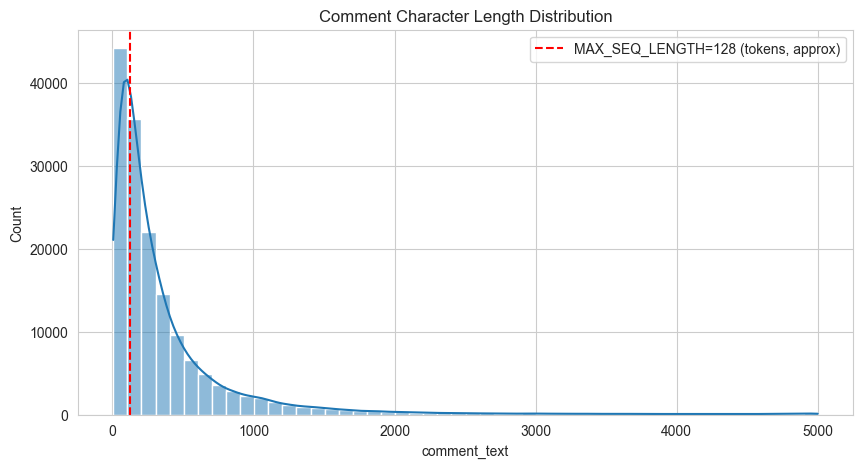

Comments longer than 500 chars: 21.27%


In [15]:
plt.figure(figsize=(10,5))
sns.histplot(train_df['comment_text'].str.len(), bins=50, kde=True)
plt.axvline(128, color='red', linestyle='--', label='MAX_SEQ_LENGTH=128 (tokens, approx)')
plt.title("Comment Character Length Distribution")
plt.legend()
plt.show()

# Kitne comments 128 tokens se lambe honge (approx, char-based estimate)
long_comments_pct = (train_df['comment_text'].str.len() > 500).sum() / total * 100
print(f"Comments longer than 500 chars: {long_comments_pct:.2f}%")

In [16]:
print("Train comment length mean:", train_df['comment_text'].str.len().mean())
print("Test comment length mean:", test_df['comment_text'].str.len().mean())

# Test set mein bhi label distribution check (sirf usable rows)
usable_test_label_counts = usable_test[label_cols].sum().sort_values(ascending=False)
print("\nTest set label distribution (usable rows):")
print(usable_test_label_counts)

Train comment length mean: 394.0732213246768
Test comment length mean: 364.8751207855632

Test set label distribution (usable rows):
toxic            6090
obscene          3691
insult           3427
identity_hate     712
severe_toxic      367
threat            211
dtype: int64


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
 8   num_labels     159571 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 11.0+ MB


In [18]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  object
 1   comment_text  153164 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB


In [20]:
test_labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             153164 non-null  object
 1   toxic          153164 non-null  int64 
 2   severe_toxic   153164 non-null  int64 
 3   obscene        153164 non-null  int64 
 4   threat         153164 non-null  int64 
 5   insult         153164 non-null  int64 
 6   identity_hate  153164 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 8.2+ MB


In [21]:
sample_submission_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             153164 non-null  object 
 1   toxic          153164 non-null  float64
 2   severe_toxic   153164 non-null  float64
 3   obscene        153164 non-null  float64
 4   threat         153164 non-null  float64
 5   insult         153164 non-null  float64
 6   identity_hate  153164 non-null  float64
dtypes: float64(6), object(1)
memory usage: 8.2+ MB


In [22]:
sample_submission_df.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.5,0.5,0.5,0.5,0.5,0.5
1,0000247867823ef7,0.5,0.5,0.5,0.5,0.5,0.5
2,00013b17ad220c46,0.5,0.5,0.5,0.5,0.5,0.5
3,00017563c3f7919a,0.5,0.5,0.5,0.5,0.5,0.5
4,00017695ad8997eb,0.5,0.5,0.5,0.5,0.5,0.5


In [23]:
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,num_labels
0,0000997932d777bf,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...",0,0,0,0,0,0,0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about...",0,0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tid...",0,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,0,0,0,0,0


In [24]:
test_df.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll ever be whats up with you and hating you sad mofuckas...i should bitch slap ur pethedic white faces and get you to kiss my ass you guys sicken me. Ja...
1,0000247867823ef7,"== From RfC == \n\n The title is fine as it is, IMO."
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lapland — / """
3,00017563c3f7919a,":If you have a look back at the source, the information I updated was the correct form. I can only guess the source hadn't updated. I shall update the information once again but thank you for your..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [25]:
test_labels_df.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1
3,00017563c3f7919a,-1,-1,-1,-1,-1,-1
4,00017695ad8997eb,-1,-1,-1,-1,-1,-1


In [26]:
train_df['comment_text']

0         Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...
1                                                                                                D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
2         Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about...
3         "\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I think the references may need tid...
4                                                                                                                                             You, sir, are my h

In [29]:
from src.data.preprocess import get_tokenizer, load_train_df

tokenizer = get_tokenizer()
df_clean = load_train_df()  # already cleaned + empty-filtered
sample = df_clean['comment_text'].sample(5000, random_state=42)
token_lengths = sample.apply(lambda x: len(tokenizer.encode(x)))

print(token_lengths.describe())
print(f"\n% of comments exceeding 128 tokens: {(token_lengths > 128).sum() / len(token_lengths) * 100:.2f}%")
print(f"% of comments exceeding 256 tokens: {(token_lengths > 256).sum() / len(token_lengths) * 100:.2f}%")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

2026-08-28 11:44:30,891 | src.data.preprocess | INFO | Loading E:\ML\sentinelai\data\raw\train.csv
2026-08-28 11:44:52,851 | src.data.preprocess | INFO | Dropped 13 train rows that became empty after cleaning


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (841 > 512). Running this sequence through the model will result in indexing errors


count    5000.00000
mean       89.10880
std       133.78586
min         4.00000
25%        24.00000
50%        48.00000
75%        98.00000
max      2034.00000
Name: comment_text, dtype: float64

% of comments exceeding 128 tokens: 17.24%
% of comments exceeding 256 tokens: 6.42%
